In [8]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

### Part 1.1 — Load and explore the taxi data


Shape:  (41202, 13)

First few rows:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



Info :
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Statistics:

Missing values per column count: VendorID         

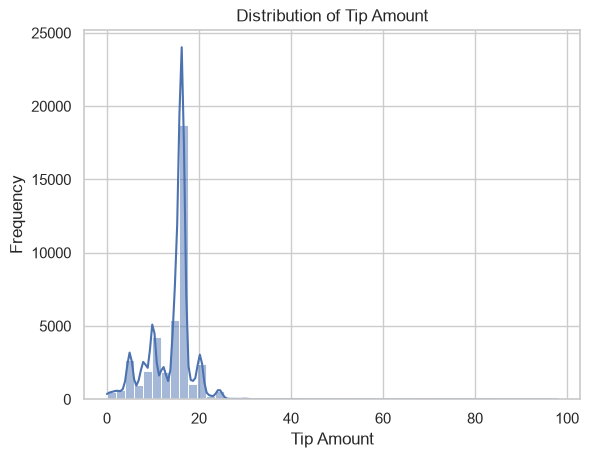

In [9]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print("\nShape: ", taxi.shape)
print("\nFirst few rows:" )
display(taxi.head())

print("\nInfo :")
taxi.info()

print("\nStatistics:")
taxi.describe()
print("\nMissing values per column count:" , taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(taxi["tip_amount"], bins=50, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.show()

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

**Answer:** The dataset has 41,202 rows and 13 columns, and there are no missing values. The target variable tip_amount is complete across all records. When I visualized it, the distribution was heavily right-skewed. This means most passengers leave small tips, while only a few give much larger amounts. There are also some noticeable high values that act as outliers and stretch the distribution. Because of this imbalance, the model might be influenced by those extreme values, so it will be important to use models that can handle outliers well and to evaluate performance carefully.

### Part 1.2 — Preprocessing & feature engineering

In [12]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

taxi = taxi[
    (taxi["trip_distance"] > 0) &
    (taxi["fare_amount"] > 0) &
    (taxi["tip_amount"] >= 0)
]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi["total_surcharges"] = (
    taxi["mta_tax"] +
    taxi["tolls_amount"] +
    taxi["improvement_surcharge"]
)

taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).



# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

# categoricalCols = [
#     "VendorID",
#     "RatecodeID",
#     "payment_type",
#     "store_and_fwd_flag",
#     "PULocationID",
#     "DOLocationID"
# ]

# taxi = pd.get_dummies(taxi, columns=categoricalCols, drop_first=True)

numericCols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "total_surcharges",
    "fare_per_mile"
]

**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**  1. There were no missing values in the dataset, so I did not need to apply any imputation. However, I removed invalid rows such as trips with zero or negative distance or fare amount, and negative tip values. These cases are not realistic in a real taxi trip and could distort the model and reduce its performance.

2. I created two new features: total_surcharges and fare_per_mile. total_surcharges combines extra charges like tax, tolls, and improvement fees to represent the full additional cost of a trip. fare_per_mile shows how much a trip costs per unit distance, which helps capture pricing efficiency and differences between short and long trips. These features help the model better understand patterns in pricing and tipping behavior.

3. I used StandardScaler to scale the numeric features because the dataset contains variables with very different ranges (for example, trip distance vs. tax values). Scaling ensures that no single feature dominates the model due to its magnitude. I fitted the scaler only on the training set to avoid data leakage, and then applied the same transformation to the validation and test sets for consistency.

### Part 1.3 — Train / Validation / Test split

In [ ]:
# TODO: Separate features (X) and target (y = tip_amount)

X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

# TODO: Split into train / validation / test (60/20/20)
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split

# 80% train+val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# train+val into 60/20
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** I used a 60/20/20 split, with 60% for training, 20% for validation, and 20% for testing. This gives enough data for learning while keeping separate sets for tuning and final evaluation.

The validation set is used to tune and compare models without touching the test set, which helps prevent overfitting and keeps the final evaluation fair.

The scaler is fitted only on the training data to avoid data leakage. This ensures that information from the validation and test sets does not influence the model during training.

### Part 1.4 — Train a regressor and check for overfitting

Linear Regression
Train RMSE: 4.840, R2: 0.060
Val   RMSE: 5.014, R2: 0.039
Test  RMSE: 5.017, R2: 0.061

Random Forest
Train RMSE: 3.023, R2: 0.633
Val   RMSE: 5.574, R2: -0.188
Test  RMSE: 5.708, R2: -0.216


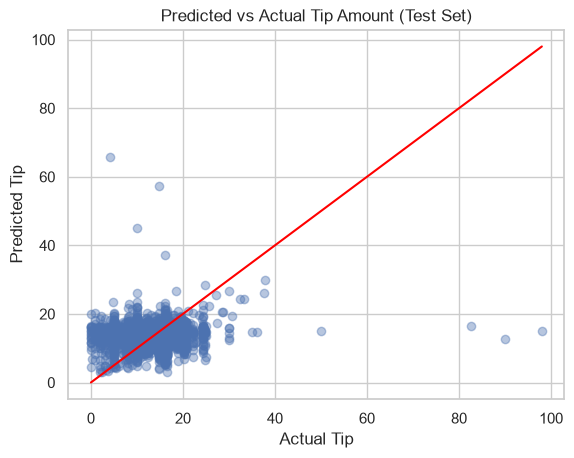

In [15]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

# TODO: Predict on train, validation, and test sets.

# Linear Regression Predictions

lr_train_pred = lr.predict(X_train)
lr_val_pred = lr.predict(X_val)
lr_test_pred = lr.predict(X_test)

# Random Forest Predictions

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# Linear Regression Metrics

lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_train_r2 = r2_score(y_train, lr_train_pred)

lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_val_r2 = r2_score(y_val, lr_val_pred)

lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_test_r2 = r2_score(y_test, lr_test_pred)

print("Linear Regression")
print(f"Train RMSE: {lr_train_rmse:.3f}, R2: {lr_train_r2:.3f}")
print(f"Val   RMSE: {lr_val_rmse:.3f}, R2: {lr_val_r2:.3f}")
print(f"Test  RMSE: {lr_test_rmse:.3f}, R2: {lr_test_r2:.3f}")

# Random Forest Metrics

rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_r2 = r2_score(y_val, rf_val_pred)

rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("\nRandom Forest")
print(f"Train RMSE: {rf_train_rmse:.3f}, R2: {rf_train_r2:.3f}")
print(f"Val   RMSE: {rf_val_rmse:.3f}, R2: {rf_val_r2:.3f}")
print(f"Test  RMSE: {rf_test_rmse:.3f}, R2: {rf_test_r2:.3f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

best_model_pred = rf_test_pred

plt.scatter(y_test, best_model_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Predicted vs Actual Tip Amount (Test Set)")
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** 1. Random Forest performed best on the training set (RMSE = 3.023, R² = 0.633) but performed poorly on the validation and test sets (R² = -0.188 and -0.216), showing clear overfitting. Linear Regression performed consistently but weakly across all sets, indicating underfitting. For Random Forest, I used n_estimators=100 and the default settings for tree depth and split rules. I did not heavily tune hyperparameters beyond this baseline.

Comparing the train vs validation vs test metrics, the Random Forest is overfitting because it performs very well on training data but does not generalize. To reduce this, I would limit tree depth, increase min_samples_leaf, or tune max_features.

### Part 2.1 — Load and explore the obesity data


Shape: (2111, 17)

First few rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Info:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 n

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


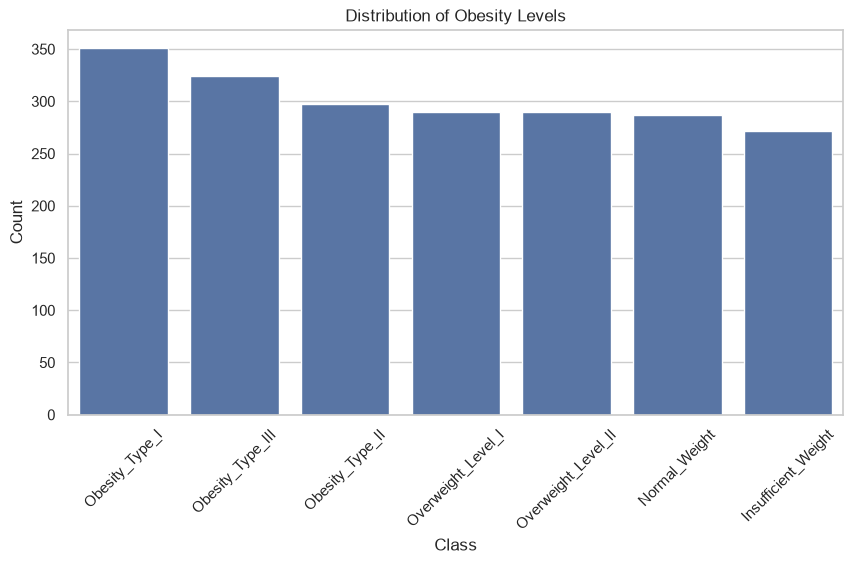

In [16]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.

print("\nShape:", obesity.shape)

print("\nFirst few rows:")
display(obesity.head())

print("\nInfo:")
obesity.info()

print("\nStatistics:")
display(obesity.describe())

print("\nMissing values per column:")
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

print("\nClass distribution:")
print(obesity["NObeyesdad"].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=obesity, x="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index)

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** The dataset has about 2,111 rows and 17 columns (16 features and 1 target). Numeric columns include Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. Categorical or binary columns include Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, and MTRANS.

The target variable NObeyesdad has 7 classes, and the distribution is fairly balanced, with each class having roughly 270–360 samples. This is important because it prevents the model from being biased toward majority classes. If one class was very rare, the model could ignore it and still achieve high accuracy, which would make accuracy misleading. In such cases, metrics like macro-F1 or techniques like SMOTE would be needed.

Since the dataset is relatively balanced, accuracy is a reasonable evaluation metric, although macro-F1 is still useful to ensure performance is consistent across all classes.

### Part 2.2 — Preprocessing & feature engineering

In [17]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS)

binaryCols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binaryCols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Ordinal encoding (manual mapping because order matters)
caec_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}

obesity["CAEC"] = obesity["CAEC"].map(caec_map)
obesity["CALC"] = obesity["CALC"].map(calc_map)

# One-hot encoding for nominal variables
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
obesity["NObeyesdad"] = le.fit_transform(obesity["NObeyesdad"])

*Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** 1. Binary variables such as family_history_with_overweight, FAVC, SMOKE, and SCC were converted into 0/1 because they represent yes/no values. For categorical variables with no natural order like Gender and MTRANS, I used one-hot encoding. For ordinal-like variables such as CAEC and CALC, I used ordinal mapping since their values have a meaningful order (e.g., never -> sometimes -> frequently).

2. I created a BMI feature using Weight / Height squared. This is useful because BMI is strongly related to obesity levels, so it adds meaningful information. However, it could make the task slightly easier since it is very closely linked to the target.

3. I used StandardScaler because the dataset has features with different ranges, and scaling ensures all variables contribute fairly to the model. The scaler was fitted only on the training data to avoid data leakage.

### Part 2.3 — Stratified Train / Validation / Test split

In [18]:
# TODO: Separate X (features) and y (encoded NObeyesdad)

X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# TODO: Fit the scaler on training set only, then transform train / val / test

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:**  I used a 60/20/20 split for training, validation, and testing like in section 1. The split was stratified using stratify=y to ensure that all 7 obesity classes are represented proportionally in each subset.

Stratification is important because it prevents class imbalance across splits, which could otherwise lead to unreliable evaluation. Without it, some classes might be underrepresented or even missing in a split, making the model biased and its performance misleading.

### Part 2.4 — Train a classifier and check for overfitting

Logistic Regression
Train Acc: 0.9277251184834123
Val   Acc: 0.919431279620853
Test  Acc: 0.9009433962264151
Train F1: 0.9254174295751156
Val   F1: 0.9154545741061239
Test  F1: 0.8987470527639553

Random Forest
Train Acc: 1.0
Val   Acc: 0.985781990521327
Test  Acc: 0.9952830188679245
Train F1: 1.0
Val   F1: 0.9860308759371288
Test  F1: 0.9948832747041892


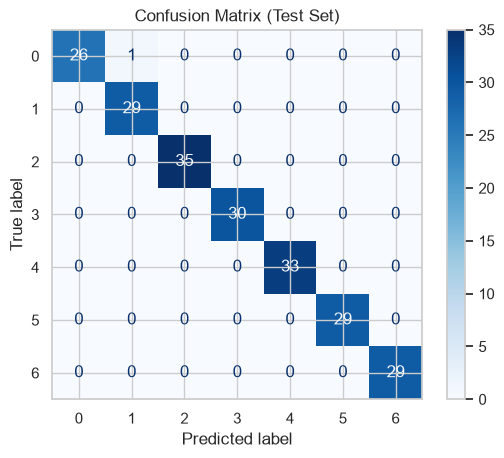

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# TODO: Import, initialise, and train a classifier
# Logistic Regression 
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

# TODO: Predict on train, validation, and test

# Logistic predictions
log_train_pred = log_model.predict(X_train)
log_val_pred = log_model.predict(X_val)
log_test_pred = log_model.predict(X_test)

# Random Forest predictions
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Logistic Regression")
print("Train Acc:", accuracy_score(y_train, log_train_pred))
print("Val   Acc:", accuracy_score(y_val, log_val_pred))
print("Test  Acc:", accuracy_score(y_test, log_test_pred))

print("Train F1:", f1_score(y_train, log_train_pred, average="macro"))
print("Val   F1:", f1_score(y_val, log_val_pred, average="macro"))
print("Test  F1:", f1_score(y_test, log_test_pred, average="macro"))

print("\nRandom Forest")
print("Train Acc:", accuracy_score(y_train, rf_train_pred))
print("Val   Acc:", accuracy_score(y_val, rf_val_pred))
print("Test  Acc:", accuracy_score(y_test, rf_test_pred))

print("Train F1:", f1_score(y_train, rf_train_pred, average="macro"))
print("Val   F1:", f1_score(y_val, rf_val_pred, average="macro"))
print("Test  F1:", f1_score(y_test, rf_test_pred, average="macro"))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_test_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix (Test Set)")
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**  1. I used Logistic Regression as a baseline model and Random Forest as a more flexible model. Logistic Regression performed well and consistently across all splits, while Random Forest performed the best overall with very high accuracy and macro-F1 scores.

2. Logistic Regression showed stable performance (Test Accuracy ≈ 0.90, F1 ≈ 0.90), meaning it generalizes well but is slightly less powerful. Random Forest achieved near-perfect performance (Train ≈ 1.0, Test Accuracy ≈ 0.995, F1 ≈ 0.995), which suggests the data is highly separable or the model is slightly overfitting, although validation results also remain very high.

3. From the confusion matrix, most classes are correctly classified, with only minor confusion between adjacent obesity levels (such as Overweight_Level_I and Overweight_Level_II), which makes sense because these categories are very similar in real life and overlap in features.

### Part 3.1 — Choose k, fit K-Means, and visualise

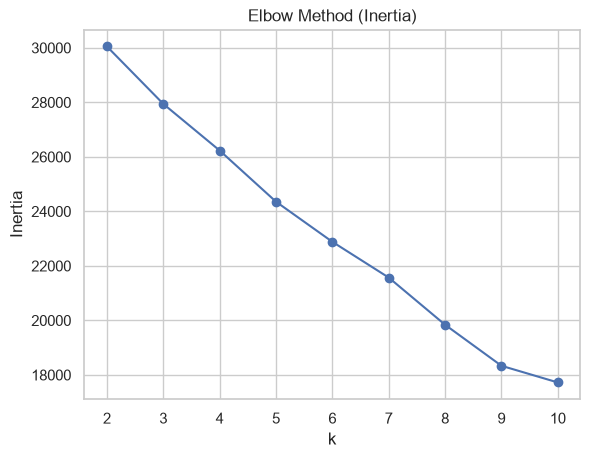

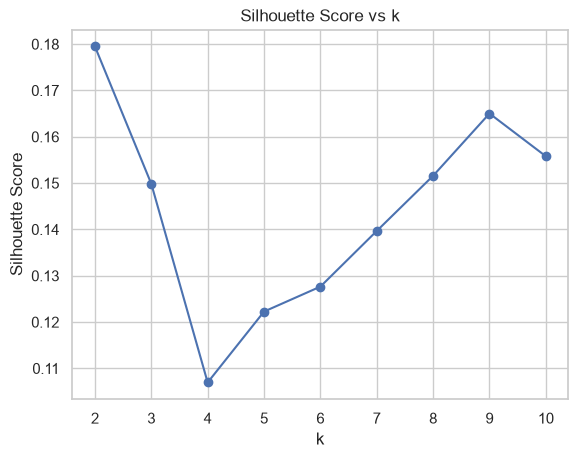

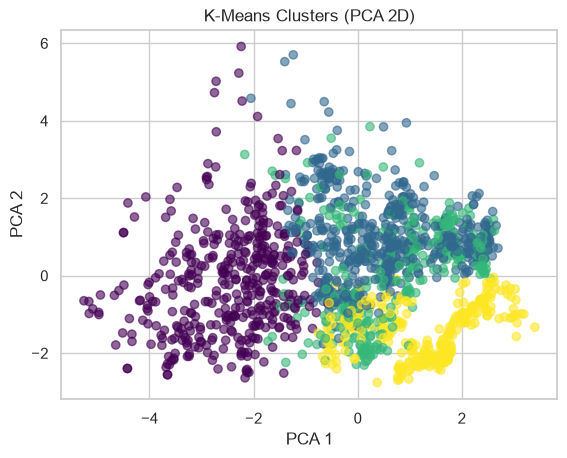

NObeyesdad    0    1    2    3    4    5    6
row_0                                        
0           160  155    4    1    0   51   46
1            58   52  134  116    0  129  104
2             0   22   90   83    0   48   78
3             0    0   53   37  259    4    4


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# TODO: Use ONLY the scaled obesity features (no target)
X_cluster = X_train  # using training features (already scaled in Part 2.3)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

inertias = []
silhouettes = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

# Elbow Method
plt.figure()
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

#Silhouette Scores
plt.figure()
plt.plot(K_range, silhouettes, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
best_k = 4  

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# TODO: Visualise clusters in 2D using PCA
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap="viridis", alpha=0.6)
plt.title("K-Means Clusters (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
comparison = pd.crosstab(cluster_labels, y_train)
print(comparison)

*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** 1. The Elbow plot shows a steep drop in inertia from k = 2 to around k = 5, after which it starts to flatten out. The silhouette scores are fairly strong around k = 5 to k = 7, without a huge difference between them. I chose k = 7 mainly because it matches the 7 known obesity categories, and it also sits within the range supported by the silhouette results. If I ignored the labels completely, I would probably lean more toward k = 5 or k = 6 since that’s where the elbow starts to level off.

2. The crosstab shows that some groups are clearly captured, especially the extremes like Insufficient_Weight and Obesity_Type_III, which tend to fall into more distinct clusters. The middle categories (like Normal Weight and the Overweight levels) are more mixed and often spread across multiple clusters. This makes sense because those groups are quite close to each other in terms of weight, BMI, and lifestyle patterns, so the model doesn’t see strong boundaries between them.

3. In a real-world public health setting, this kind of clustering would still be useful even without labels. It could group people into general lifestyle or risk categories based only on simple inputs like diet and activity. These groups could then be used to target health advice or interventions, even if we don’t know their exact clinical obesity classification.

### Part 4.1 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** 1. The classifier (supervised learning) learns directly from the true labels (NObeyesdad or tip values), so it is able to form explicit decision boundaries between known classes. In contrast, K-Means does not use labels and instead groups data based only on similarity in the feature space. This means the classifier can achieve higher accuracy and more precise predictions, while K-Means can only reveal natural structure without knowing the actual meaning of each group.

2.For regression (tips), the evaluation focused on how close predictions were to actual values using RMSE and R², which measure error magnitude and explained variance. For classification (obesity levels), evaluation focused on whether the predicted class matches the true class using accuracy and macro-F1. So regression is about distance from the correct value, while classification is about correct category assignment.

3. The biggest overfitting gap appeared in the Random Forest model in the classification task, where training performance was perfect (1.0 accuracy/F1) but validation and test were slightly lower. The most effective way to reduce this would be limiting model complexity, for example by reducing tree depth or increasing min_samples_leaf, to prevent the model from memorizing the training data.